Data directory: /home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/data


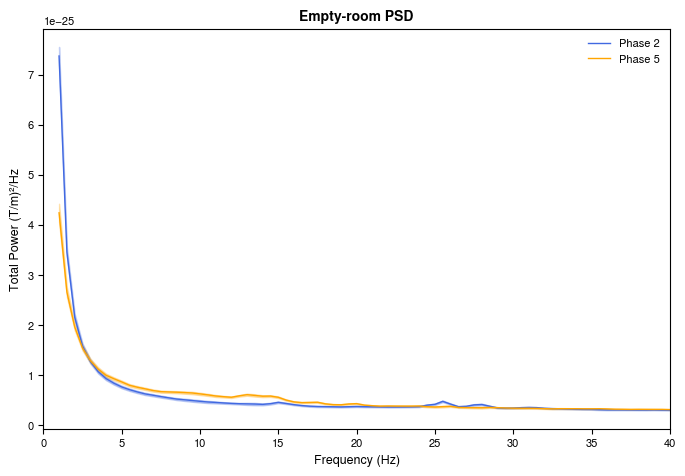

In [1]:
""" 
This script plots Supplementary Figure 08, which shows the empty-room power spectral density (PSD) for the two phases of the study. The source data is loaded from a TSV file that was saved with the script `supp_figure08_source_data.ipynb`. 
"""

import pandas as pd
import matplotlib.pyplot as plt
import os

datadir = os.path.abspath(os.path.join(os.path.dirname( os.getcwd() ), '.', 'data'))
print(f'Data directory: {datadir}')

phases = ['p2', 'p5']

# General figure settings
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"]
plt.rcParams.update({'font.size': 8}) # setting font size to 8

# Create the figure with 4 subplots
fig, ax = plt.subplots(1, 1, figsize=(7.2, 5), gridspec_kw={'wspace': 0.1, 'hspace': 0.3, 'left':0.10, 'right':0.97, 'top':0.91, 'bottom':0.11})

data_file = os.path.join(datadir, f'supp_figure08_source_data.tsv')
data_df = pd.read_csv(data_file, sep='\t')

freqs = data_df['freqs'].values
phases_spectra = [data_df['phase_2_spectrum'].values, data_df['phase_5_spectrum'].values]
spectra_sem = data_df['spectra_sem'].values
chan_units = data_df['chan_units'].values[0]

'''freqs_filter = (freqs >= 2) & (freqs <= 40)
phases_spectra = [spectrum[freqs_filter] for spectrum in phases_spectra]
spectra_sem = spectra_sem[freqs_filter] 
freqs = freqs[freqs_filter]'''

ax.plot(freqs, phases_spectra[0], label='Phase 2', color='royalblue', linewidth=1, alpha=1)
ax.fill_between(freqs, phases_spectra[0]-spectra_sem, phases_spectra[0]+spectra_sem, color='royalblue', alpha=0.3)

ax.plot(freqs, phases_spectra[1], label='Phase 5', color='orange', linewidth=1, alpha=1)
ax.fill_between(freqs, phases_spectra[1]-spectra_sem, phases_spectra[1]+spectra_sem, color='orange', alpha=0.3)

ax.set_title(f'Empty-room PSD', fontsize=10, fontweight='bold') #{group
ax.set_xlabel('Frequency (Hz)', fontsize=9)
ax.set_ylabel(f'Total Power {chan_units}', fontsize=9)
ax.set_xlim(0, 40)

ax.legend(frameon=False, fontsize=8, loc='upper right') # Legend for the dA effect plots (Right)

plt.savefig(f'Supp_Figure08.png', dpi=300, format='png', transparent=False)
plt.show()